In [ ]:
import os
import time
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ========== Конфигурация ==========
MODEL_NAME = "ai-sage/GigaChat3-10B-A1.8B-bf16"
INPUT_CSV = "../data/public/knowledge_bench_public.csv"   # тестовый датасет с метками
ARTIFACTS_DIR = "../model/"  # папка с pca.pkl, scaler.pkl, hallucination_detector.pkl

PROBE_LAYERS = [0, 5, 10, 15, 20, 25]   # те же слои, что при обучении

# ========== Загрузка артефактов ==========
with open(ARTIFACTS_DIR + "pca.pkl", "rb") as f:
    pca = pickle.load(f)
with open(ARTIFACTS_DIR + "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

xgb_model = joblib.load(ARTIFACTS_DIR + "hallucination_detector.pkl")
print("PCA, scaler и XGBoost загружены.")

# ========== Загрузка модели Gigachat (8-bit) ==========
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
    offload_folder="offload",
)
model.eval()
print("Gigachat загружена.")

PCA, scaler и XGBoost загружены.


config.json: 0.00B [00:00, ?B/s]

`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

...

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

DeepseekV3ForCausalLM LOAD REPORT from: ai-sage/GigaChat3-10B-A1.8B-bf16
Key                                                 | Status     |  | 
----------------------------------------------------+------------+--+-
model.layers.26.self_attn.q_proj.weight             | UNEXPECTED |  | 
model.layers.26.post_attention_layernorm.weight     | UNEXPECTED |  | 
model.layers.26.mlp.gate.e_score_correction_bias    | UNEXPECTED |  | 
model.layers.26.embed_tokens.weight                 | UNEXPECTED |  | 
model.layers.26.eh_proj.weight                      | UNEXPECTED |  | 
model.layers.26.mlp.experts.down_proj               | UNEXPECTED |  | 
model.layers.26.shared_head.head.weight             | UNEXPECTED |  | 
model.layers.26.mlp.shared_experts.gate_proj.weight | UNEXPECTED |  | 
model.layers.26.self_attn.kv_a_proj_with_mqa.weight | UNEXPECTED |  | 
model.layers.26.input_layernorm.weight              | UNEXPECTED |  | 
model.layers.26.mlp.shared_experts.up_proj.weight   | UNEXPECTED |  | 
mode

generation_config.json:   0%|          | 0.00/153 [00:00<?, ?B/s]

Gigachat загружена.


In [6]:
# ========== FeatureAccumulator (точно как при обучении) ==========
class FeatureAccumulator:
    def __init__(self, model, probe_layers):
        self.model = model
        self.probe_layers = probe_layers
        self._hooks = []
        self._hidden = {}
    def attach(self):
        self._hidden.clear()
        layers = self.model.model.layers
        for idx in self.probe_layers:
            if idx >= len(layers): continue
            name = f"layer_{idx}"
            def make_hook(n):
                def hook(_, __, out):
                    h = out[0] if isinstance(out, tuple) else out
                    self._hidden[n] = h.detach()
                return hook
            self._hooks.append(layers[idx].register_forward_hook(make_hook(name)))
    def detach(self):
        for h in self._hooks: h.remove()
        self._hooks.clear()
    def __enter__(self):
        self.attach()
        return self
    def __exit__(self, *args):
        self.detach()
    def compute_features(self, logits, input_ids, ans_start):
        seq_len = input_ids.shape[1]
        ans_len = seq_len - ans_start

        # --- Uncertainty features ---
        answer_logits = logits[0, ans_start-1:seq_len-1, :].float()
        answer_ids = input_ids[0, ans_start:seq_len]
        answer_ids = answer_ids.to(answer_logits.device)

        log_probs = F.log_softmax(answer_logits, dim=-1)
        token_lp = log_probs.gather(1, answer_ids.unsqueeze(1)).squeeze(-1)

        probs = F.softmax(answer_logits, dim=-1)
        entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=-1)
        top1 = probs.max(dim=-1).values
        top5 = probs.topk(min(5, probs.shape[-1]), dim=-1).values.sum(dim=-1)

        uncertainty = np.array([
            token_lp.mean().item(), token_lp.min().item(), token_lp.max().item(),
            token_lp.std().item() if ans_len > 1 else 0.0,
            entropy.mean().item(), entropy.max().item(),
            entropy.std().item() if ans_len > 1 else 0.0,
            torch.exp(-token_lp.mean()).item(), float(ans_len), token_lp[0].item(),
            top1.mean().item(), top5.mean().item()
        ], dtype=np.float32)

        # --- Internal features & probe vector ---
        last_hs = self._hidden[f"layer_{self.probe_layers[-1]}"][0]
        probe_vec = last_hs[ans_start-1].cpu().float().numpy()

        int_scalars = []
        for idx in self.probe_layers:
            hs = self._hidden[f"layer_{idx}"][0]
            int_scalars.append(hs[ans_start-1].norm().item())
            int_scalars.append(hs[ans_start:seq_len].norm(dim=-1).mean().item())

            ans_hs = hs[ans_start-1:seq_len-1].unsqueeze(0)
            with torch.no_grad():
                norm_hs = self.model.model.norm(ans_hs)
                ll = self.model.lm_head(norm_hs).float()
            ll_p = torch.softmax(ll[0], dim=-1)
            ll_e = -(ll_p * torch.log(ll_p + 1e-10)).sum(dim=-1)
            int_scalars.append(ll_e.mean().item())

        first_e, last_e = int_scalars[2], int_scalars[-1]
        int_scalars.append(first_e - last_e)
        int_scalars.append(last_e / (first_e + 1e-10))

        internal = np.array(int_scalars, dtype=np.float32)
        self._hidden.clear()
        return {"uncertainty": uncertainty, "internal_scalars": internal, "probe_vec": probe_vec}

In [7]:
# ========== Препроцессинг (точно как при обучении) ==========
def preprocess(tokenizer, prompt, answer):
    prompt_enc = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        add_generation_prompt=True,
        tokenize=True
    )
    ans_start = len(prompt_enc["input_ids"])

    full_enc = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}, {"role": "assistant", "content": answer}],
        tokenize=True
    )
    tok_ids = torch.tensor([full_enc["input_ids"]], dtype=torch.long)
    return tok_ids, ans_start

# ========== Загрузка тестовых данных ==========
df_test = pd.read_csv(INPUT_CSV)
print(f"Загружено примеров: {len(df_test)}")

Загружено примеров: 1044


In [8]:
# ========== Инференс ==========
accumulator = FeatureAccumulator(model, PROBE_LAYERS)

t_model_list = []
t_overhead_list = []
pred_probas = []
y_true = []

for idx, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Inference"):
    prompt = row["prompt"]
    answer = row["model_answer"]
    label = row["is_hallucination"]
    y_true.append(1 if label else 0)

    # 1. Токенизация
    tok, ans_start = preprocess(tokenizer, prompt, answer)
    tok = tok.to(model.device)

    # 2. Forward pass Gigachat (время не учитывается в overhead)
    t0 = time.perf_counter()
    with accumulator, torch.no_grad():
        out = model(tok)
    t_model = time.perf_counter() - t0

    # 3. Извлечение признаков и подготовка вектора для классификатора
    t1 = time.perf_counter()
    feats = accumulator.compute_features(out.logits, tok, ans_start)

    probe_vec = feats["probe_vec"].reshape(1, -1)
    internal = feats["internal_scalars"].reshape(1, -1)
    uncertainty = feats["uncertainty"].reshape(1, -1)

    probe_pca = pca.transform(probe_vec)
    X = np.hstack([probe_pca, internal, uncertainty])
    X_scaled = scaler.transform(X)

    # 4. Предсказание XGBoost
    proba = xgb_model.predict_proba(X_scaled)[0, 1]  # вероятность класса 1 (галлюцинация)
    t_overhead = time.perf_counter() - t1

    pred_probas.append(proba)
    t_model_list.append(t_model * 1000)   # в мс
    t_overhead_list.append(t_overhead * 1000)

    # Очистка
    del out, tok
    torch.cuda.empty_cache()

y_true = np.array(y_true)
pred_probas = np.array(pred_probas)

Inference: 100%|██████████| 1044/1044 [09:50<00:00,  1.77it/s]


In [ ]:
# ========== Вычисление метрик ==========
# Базовые метрики при пороге 0.5
y_pred = (pred_probas >= 0.1).astype(int)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# AUC метрики
pr_auc = average_precision_score(y_true, pred_probas)
roc_auc = roc_auc_score(y_true, pred_probas)

print("\n===== Метрики =====")
print(f"PR-AUC:   {pr_auc:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision:{precision:.4f}")
print(f"Recall:   {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# ========== Статистика времени ==========
print("\n===== Timing (per sample) =====")
print(f"  model forward (не учитывается): {np.mean(t_model_list):.1f} ms (mean), max {np.max(t_model_list):.1f} ms")
print(f"  overhead (XGBoost + feature prep): {np.mean(t_overhead_list):.2f} ms (mean), max {np.max(t_overhead_list):.2f} ms")
print(f"  overhead p99: {np.percentile(t_overhead_list, 99):.2f} ms")
overhead_ok = np.percentile(t_overhead_list, 99) < 500
print(f"  {'✅ PASS' if overhead_ok else '❌ FAIL'}: p99 overhead < 500 ms")

# ========== Сохранение результатов с вероятностями ==========
df_result = df_test.copy()
df_result["predict_proba"] = pred_probas
df_result["predict_label"] = y_pred
OUTPUT_RESULT_CSV = "../data/public/knowledge_bench_public_results.csv"
df_result.to_csv(OUTPUT_RESULT_CSV, index=False)
print(f"\nРезультаты сохранены в {OUTPUT_RESULT_CSV}")


===== Метрики =====
PR-AUC:   0.7029
ROC-AUC:  0.6397
Accuracy: 0.6054
Precision:0.6816
Recall:   0.5106
F1-score: 0.5838

===== Timing (per sample) =====
  model forward (не учитывается): 485.0 ms (mean), max 1479.1 ms
  overhead (XGBoost + feature prep): 69.07 ms (mean), max 194.50 ms
  overhead p99: 134.79 ms
  ✅ PASS: p99 overhead < 500 ms

Результаты сохранены в /kaggle/working/knowledge_bench_public_results.csv


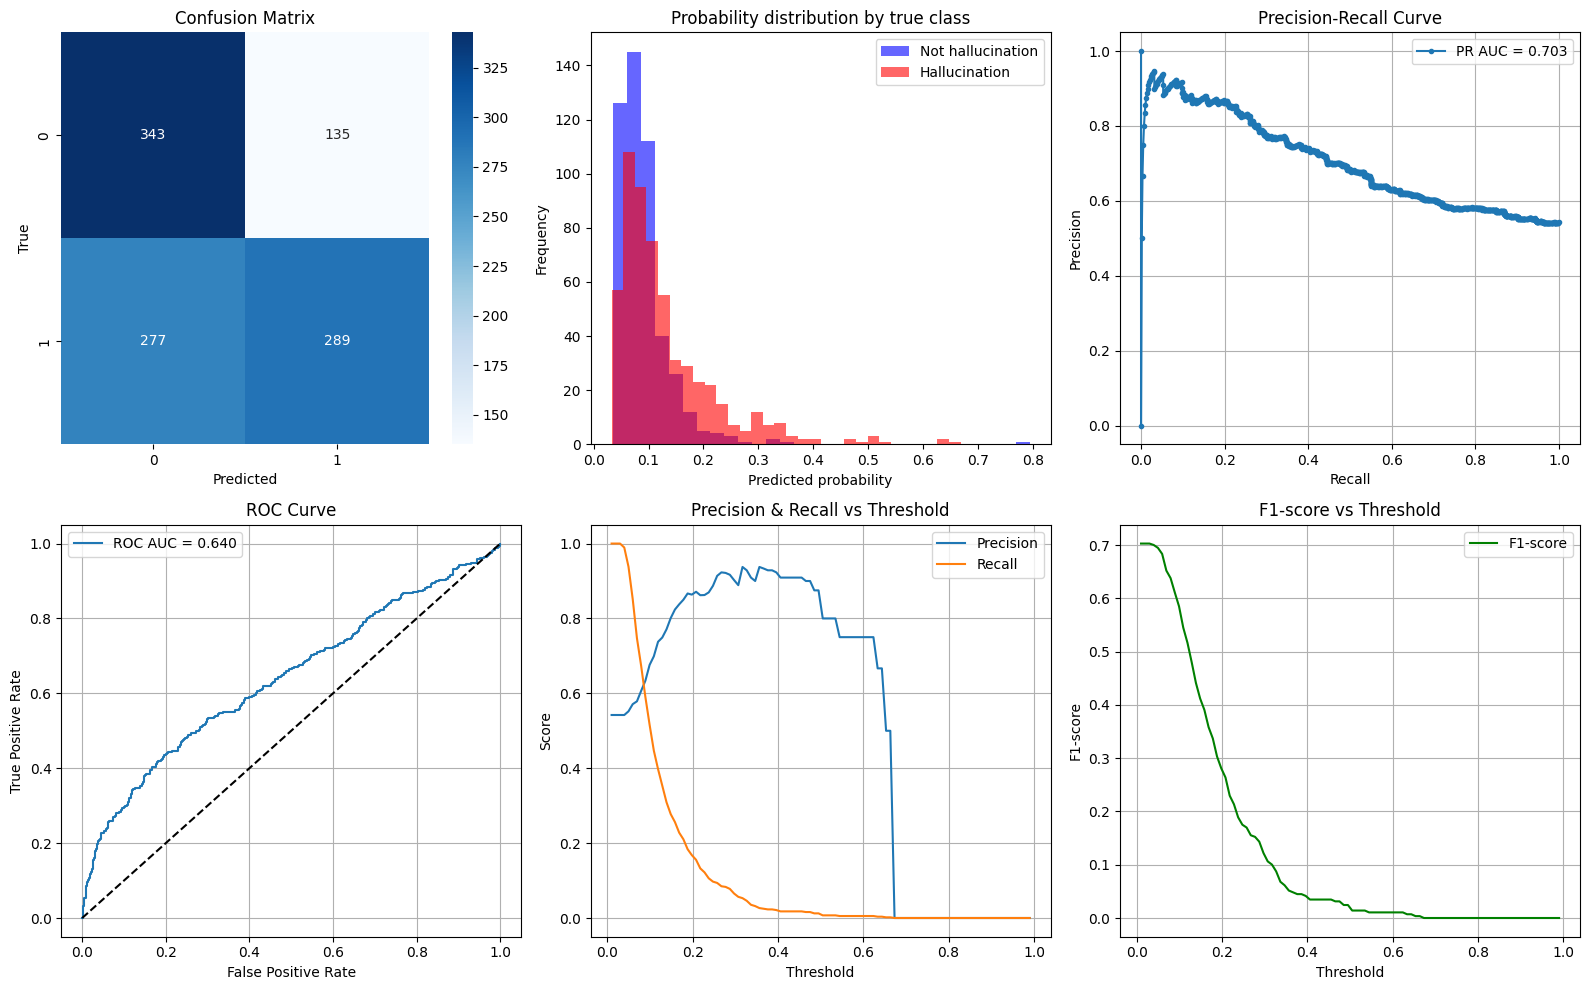

In [19]:
# ========== Графики ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('True')

# 2. Распределение вероятностей по классам
axes[0,1].hist(pred_probas[y_true==0], bins=30, alpha=0.6, label='Not hallucination', color='blue')
axes[0,1].hist(pred_probas[y_true==1], bins=30, alpha=0.6, label='Hallucination', color='red')
axes[0,1].set_xlabel('Predicted probability')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Probability distribution by true class')
axes[0,1].legend()

# 3. Precision-Recall кривая
precisions, recalls, thresholds_pr = precision_recall_curve(y_true, pred_probas)
axes[0,2].plot(recalls, precisions, marker='.', label=f'PR AUC = {pr_auc:.3f}')
axes[0,2].set_xlabel('Recall')
axes[0,2].set_ylabel('Precision')
axes[0,2].set_title('Precision-Recall Curve')
axes[0,2].legend()
axes[0,2].grid(True)

# 4. ROC кривая
fpr, tpr, _ = roc_curve(y_true, pred_probas)
axes[1,0].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
axes[1,0].plot([0,1], [0,1], 'k--')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curve')
axes[1,0].legend()
axes[1,0].grid(True)

# 5. Precision, Recall vs порог
# Выбираем разумный диапазон порогов (исключаем 0 и 1 для наглядности)
thresholds = np.linspace(0.01, 0.99, 100)
prec_at_thresh = [precision_score(y_true, pred_probas >= t) for t in thresholds]
rec_at_thresh = [recall_score(y_true, pred_probas >= t) for t in thresholds]
axes[1,1].plot(thresholds, prec_at_thresh, label='Precision')
axes[1,1].plot(thresholds, rec_at_thresh, label='Recall')
axes[1,1].set_xlabel('Threshold')
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Precision & Recall vs Threshold')
axes[1,1].legend()
axes[1,1].grid(True)

# 6. F1-score vs порог (дополнительно)
f1_at_thresh = [f1_score(y_true, pred_probas >= t) for t in thresholds]
axes[1,2].plot(thresholds, f1_at_thresh, label='F1-score', color='green')
axes[1,2].set_xlabel('Threshold')
axes[1,2].set_ylabel('F1-score')
axes[1,2].set_title('F1-score vs Threshold')
axes[1,2].legend()
axes[1,2].grid(True)

plt.tight_layout()
plt.show()